# Review
last time we talked about Pandas python library (used for mainly tabular data analysis)
- df.head(n)  - view n first rows
- df.tail(n)  - view n last rows
- df.info() - check data info
- .loc[...] - to select data using row and column labels (names).
- .iloc[...] - to select data using integer positions
- df.sort_values(...) - sorts values
- df.isnull() - to check for missing data
- df[col_name].value_counts() - return the number of times each unique value appears in a column
- df.groupby(...) - for group analysis
- df[col_name].unique() - get the unique values of a column


recommended Environments: google colab / Anaconda distribution

# kaggle
Kaggle is an online platform for data science where you can find datasets, write and share notebooks, and practice machine learning through projects and competitions.

### Generate Your Kaggle API Token
1. Go to Kaggle.
2. Click on your Profile → Account.
3. Scroll down to API and click Create New API Token.
4. A file named kaggle.json will be downloaded to your computer.

install and configure kaggle

In [ ]:
# Install the Kaggle library
!pip install kaggle

In [ ]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [ ]:
# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
# sanity check
!kaggle datasets list

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                        BMW Global Automotive Sales                             55017  2026-02-22 18:18:38.170000          11370        230                1  
ssssws/chocolate-sales-dataset-2023-2024                        Chocolate Sales Dataset 2023 - 2024                  24420255  2026-03-07 04:58:02.387000           3626         69                1  
sahilislam007/spotify-user-behavior-and-pattern                 Spotify User Behavior And Pattern                     1045077  2026-03-12 07:13:26.360000            898         29                1  
muham

Download 'Friends' TV show dataset

In [11]:
!kaggle datasets download rezaghari/friends-series-dataset
!unzip friends-series-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/rezaghari/friends-series-dataset
License(s): copyright-authors
friends-series-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  friends-series-dataset.zip
replace friends_episodes_v2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [44]:
import pandas as pd

data = pd.read_csv('./friends_episodes_v2.csv')
data

,Year_of_prod,Season,Episode_Title,Duration,Summary,Director,Stars,Votes
0,1994,1,The One with the Sonogram at the End,22,Ross finds out his ex-wife is pregnant. Rachel...,James Burrows,8.1,4888
1,1994,1,The One with the Thumb,22,Monica becomes irritated when everyone likes h...,James Burrows,8.2,4605
2,1994,1,The One with George Stephanopoulos,22,Joey and Chandler take Ross to a hockey game t...,James Burrows,8.1,4468
3,1994,1,The One with the East German Laundry Detergent,22,"Eager to spend time with Rachel, Ross pretends...",Pamela Fryman,8.5,4438
4,1994,1,The One with the Butt,22,Monica's obsessiveness is put to the test afte...,Arlene Sanford,8.1,4274
...,...,...,...,...,...,...,...,...
230,2004,10,The One with Princess Consuela,22,When Phoebe goes to get her name changed she r...,Gary Halvorson,8.6,2989
231,2004,10,The One Where Estelle Dies,22,Ross tries to get Rachel to go back to Ralph L...,Gary Halvorson,8.5,2771
232,2004,10,The One with Rachel's Going Away Party,22,"The gang throws Rachel a goodbye party, during...",Gary Halvorson,8.9,3141
233,2004,10,The Last One,30,Erica gives birth to the baby that Monica and ...,Kevin Bright,9.5,6221


# EDA (exploratory data analysis)
lets explore the dataset.
- Answer the following

In [45]:
# what is the type of each column?
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year_of_prod   235 non-null    int64  
 1   Season         235 non-null    int64  
 2   Episode_Title  235 non-null    object 
 3   Duration       235 non-null    int64  
 4   Summary        235 non-null    object 
 5   Director       235 non-null    object 
 6   Stars          235 non-null    float64
 7   Votes          235 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 14.8+ KB


In [46]:
# get the episode titles appearing in rows indexed 20-25:
#   data['Episode_Title'].iloc[20:26]
#   data.loc[20:25, 'Episode_Title']
data.loc[20:25, "Episode_Title"].tolist()

['The One with the Ick Factor',
 'The One with the Birth',
 'The One Where Rachel Finds Out',
 "The One with Ross's New Girlfriend",
 'The One with the Breast Milk',
 'The One Where Heckles Dies']

In [38]:
# does the dataset contain missing values?
data.isnull().sum().sum()

np.int64(0)

In [48]:
# sort the dataset based on 'Director' column, use inplace=True to apply directly to the original DataFrame
data.sort_values('Director', inplace = True)
data

,Year_of_prod,Season,Episode_Title,Duration,Summary,Director,Stars,Votes
13,1995,1,The One with the Stoned Guy,22,Monica cooks a gourmet meal for a restaurateur...,Alan Myerson,8.2,3915
11,1995,1,The One with the Boobies,22,Joey finds out his dad has a mistress. Rachel ...,Alan Myerson,8.7,4172
111,1999,5,The One with the Cop,22,Joey has a dream about Monica and becomes conv...,Andrew Tsao,8.6,3174
4,1994,1,The One with the Butt,22,Monica's obsessiveness is put to the test afte...,Arlene Sanford,8.1,4274
184,2002,8,The One Where Joey Tells Rachel,22,Ross freaks out when Joey tells him that he is...,Ben Weiss,8.3,2698
...,...,...,...,...,...,...,...,...
211,2003,9,The One with Rachel's Dream,22,Joey is insecure now his Days of Our Lives cha...,Terry Hughes,8.1,2616
65,1997,3,The One with the Tiny T-Shirt,22,"Rachel goes on her first date, after splitting...",Terry Hughes,8.2,3147
33,1996,2,The One with the Lesbian Wedding,22,Rachel's mom comes to visit with big news. Mon...,Thomas Schlamme,8.1,3524
32,1996,2,The One with Russ,22,Monica gets back together with 'Fun Bobby' and...,Thomas Schlamme,8.0,3591


notice how the index changed

In [49]:
print(data["Episode_Title"].iloc[0])
print(data["Episode_Title"].loc[0])

The One with the Stoned Guy
The One with the Sonogram at the End


you can access the index values using .index[]:  


In [ ]:
data.index[0]

np.int64(13)

In [50]:
# who are the show's directors?
data['Director'].unique()


array(['Alan Myerson', 'Andrew Tsao', 'Arlene Sanford', 'Ben Weiss',
       'Dana De Vally Piazza', 'David Schwimmer', 'David Steinberg',
       'Ellen Gittelsohn', 'Gail Mancuso', 'Gary Halvorson',
       'James Burrows', 'Joe Regalbuto', 'Kevin Bright', 'Mary Kay Place',
       'Michael Lembeck', 'Pamela Fryman', 'Paul Lazarus', 'Peter Bonerz',
       'Robby Benson', 'Roger Christiansen', 'Sam Simon', 'Sheldon Epps',
       'Shelley Jensen', 'Stephen Prime', 'Steve Zuckerman',
       'Terry Hughes', 'Thomas Schlamme', 'Todd Holland'], dtype=object)

In [75]:
# which director directed the highest number of episodes?
data['Director'].value_counts().


,count
Director,
Kevin Bright,54
Gary Halvorson,54
Michael Lembeck,24
Gail Mancuso,14
James Burrows,14
Peter Bonerz,12
David Schwimmer,10
Ben Weiss,10
Robby Benson,6


In [130]:
# create a new column called 'DirectorCategory' containing the directors' names,
# directors that directed less than 5 episodes should be written as 'Others'.

# Calculate director counts once for efficiency
director_counts = data['Director'].value_counts()

# Define a function to categorize directors
def director_category(d):
  if director_counts[d] >= 5:
   return d
  else:
   return "Others"

# Apply the function to create the new column
data['DirectorCategory'] = data['Director'].apply(director_category)

In [ ]:
data.head()

In [67]:
# what is the average stars rating for each director's episodes?
data.groupby('Director')['Stars'].mean()


,Stars
Director,
Alan Myerson,8.450000
Andrew Tsao,8.600000
Arlene Sanford,8.100000
Ben Weiss,8.300000
Dana De Vally Piazza,8.400000
David Schwimmer,8.540000
David Steinberg,8.500000
Ellen Gittelsohn,8.300000
Gail Mancuso,8.357143


In [134]:
# How many episodes did each director direct per season?
# Hint: use groupby for multiple columns
data.groupby(['Director', 'Season']).count()["Episode_Title"]


Director         Season
Alan Myerson     1         2
Andrew Tsao      5         1
Arlene Sanford   1         1
Ben Weiss        6         1
                 7         1
                          ..
Steve Zuckerman  3         2
Terry Hughes     3         4
                 9         1
Thomas Schlamme  2         2
Todd Holland     5         1
Name: Episode_Title, Length: 76, dtype: int64

<Axes: >

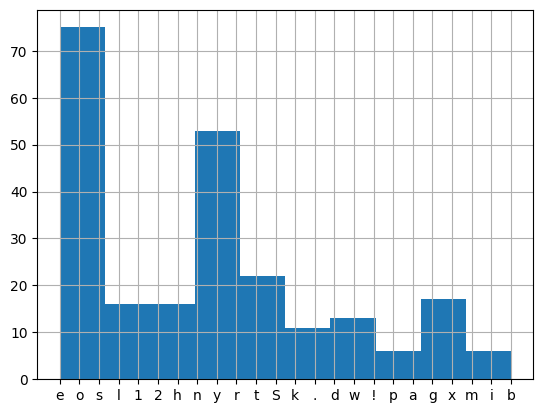

In [137]:
# what the last letter of each episode title? visualize the distribution using histogram
data['Episode_Title'].str[-1].hist()
